In [ ]:
# Run all_comparison.py to get the results printed to the console.

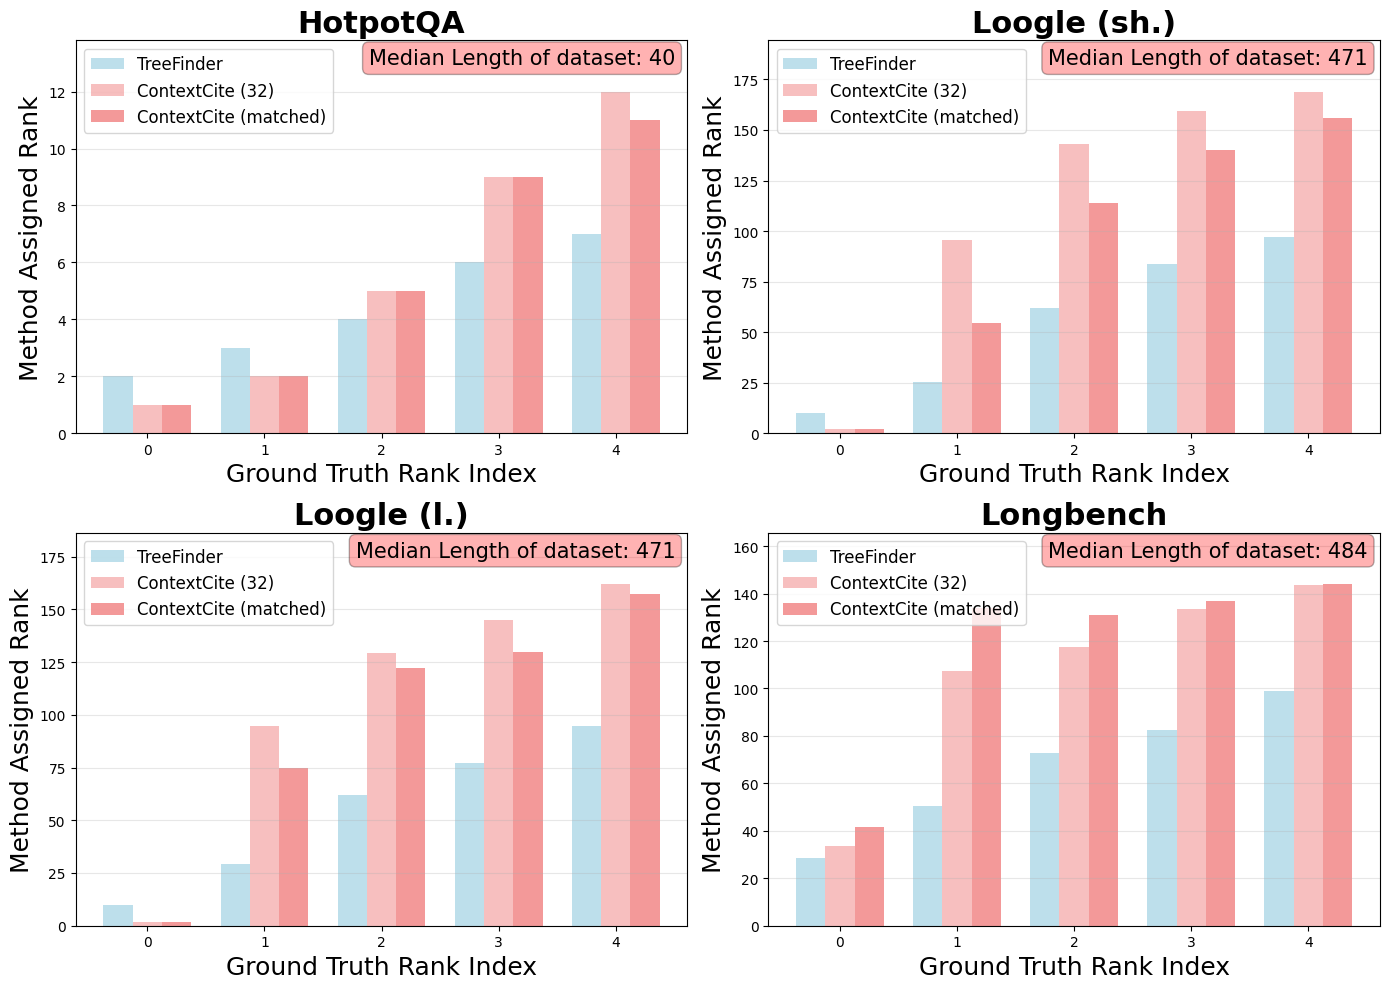

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

hotpot_qa_median_length = 40
loogle_median_length = 471
longbench_median_length = 484

tf = {}
cc = {}

tf["HotpotQA"] = {
    "Rank": [2.0, 3.0, 4.0, 6.0, 7.0],
    "Time": 5.70,
    "Calls": 46.8
}
tf["Loogle (sh.)"] = {
    "Rank": [10.0, 25.5, 62.0, 83.5, 97.0],
    "Time": 81.38,
    "Calls": 97.4
}
tf["Loogle (l.)"] = {
    "Rank": [10.0, 29.5, 62.0, 77.0, 94.5],
    "Time": 79.58,
    "Calls": 97.1
}
tf["Longbench"] = {
    "Rank": [28.5, 50.5, 73.0, 82.5, 99.0],
    "Time": 82.41,
    "Calls": 98.9
}

cc["HotpotQA (32)"] = {
    "Rank": [1.0, 2.0, 5.0, 9.0, 12.0],
    "Time": 5.83,
    "Calls": 32
}
cc["HotpotQA (50)"] = {
    "Rank": [1.0, 2.0, 5.0, 9.0, 11.0],
    "Time": 9.65,
    "Calls": 50
}
cc["Loogle (sh.) (32)"] = {
    "Rank": [2.0, 95.5, 143.0, 159.5, 169.0],
    "Time": 33.24,
    "Calls": 32
}
cc["Loogle (sh.) (100)"] = {
    "Rank": [2.0, 54.5, 114.0, 140.0, 156.0],
    "Time": 91.11,
    "Calls": 100
}
cc["Loogle (l.) (32)"] = {
    "Rank": [2.0, 94.5, 129.5, 145.0, 162.0],
    "Time": 34.28,
    "Calls": 32
}
cc["Loogle (l.) (100)"] = {
    "Rank": [2.0, 75.0, 122.0, 130.0, 157.5],
    "Time": 89.92,
    "Calls": 100
}
cc["Longbench (32)"] = {
    "Rank": [33.5, 107.5, 117.5, 133.5, 143.5],
    "Time": 32.35,
    "Calls": 32
}
cc["Longbench (100)"] = {
    "Rank": [41.5, 134.0, 131.0, 137.0, 144.0],
    "Time": 89.92,
    "Calls": 100
}

# Organize data for plotting
datasets = ["HotpotQA", "Loogle (sh.)", "Loogle (l.)", "Longbench"]
median_lengths = [hotpot_qa_median_length, loogle_median_length, loogle_median_length, longbench_median_length]

# Create 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, ds in enumerate(datasets):
    ax = axes[idx]
    
    # Get ranks for each method
    tf_ranks = tf[ds]["Rank"]
    cc_32_ranks = cc[f"{ds} (32)"]["Rank"]
    cc_matched_key = f"{ds} (50)" if ds == "HotpotQA" else f"{ds} (100)"
    cc_matched_ranks = cc[cc_matched_key]["Rank"]
    
    # Create x positions for each rank value
    width = 0.25
    x_tf = np.arange(len(tf_ranks))
    x_cc32 = np.arange(len(cc_32_ranks))
    x_ccm = np.arange(len(cc_matched_ranks))
    
    # Plot bars
    ax.bar(x_tf - width, tf_ranks, width, label='TreeFinder', alpha=0.8, color="lightblue")
    ax.bar(x_cc32, cc_32_ranks, width, label='ContextCite (32)', alpha=0.5, color="lightcoral")
    ax.bar(x_ccm + width, cc_matched_ranks, width, label='ContextCite (matched)', alpha=0.8, color="lightcoral")
    
    # Determine y-axis limits based on data
    max_rank = max(max(tf_ranks), max(cc_32_ranks), max(cc_matched_ranks))
    
    # Set y-limit to just above the maximum rank value, add text annotation for median
    ax.set_ylim(0, max_rank * 1.15)
    
    # Add text annotation for median length instead of a line
    ax.text(0.98, 0.98, f'Median Length of dataset: {median_lengths[idx]}', 
            transform=ax.transAxes, fontsize=15, verticalalignment='top', 
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
    
    # Customize subplot
    ax.set_xlabel('Ground Truth Rank Index', fontsize=18)
    ax.set_ylabel('Method Assigned Rank', fontsize=18)
    ax.set_title(f'{ds}', fontsize=22, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.show()

# Save as PDF
fig.savefig('results/comparison_plot.pdf')

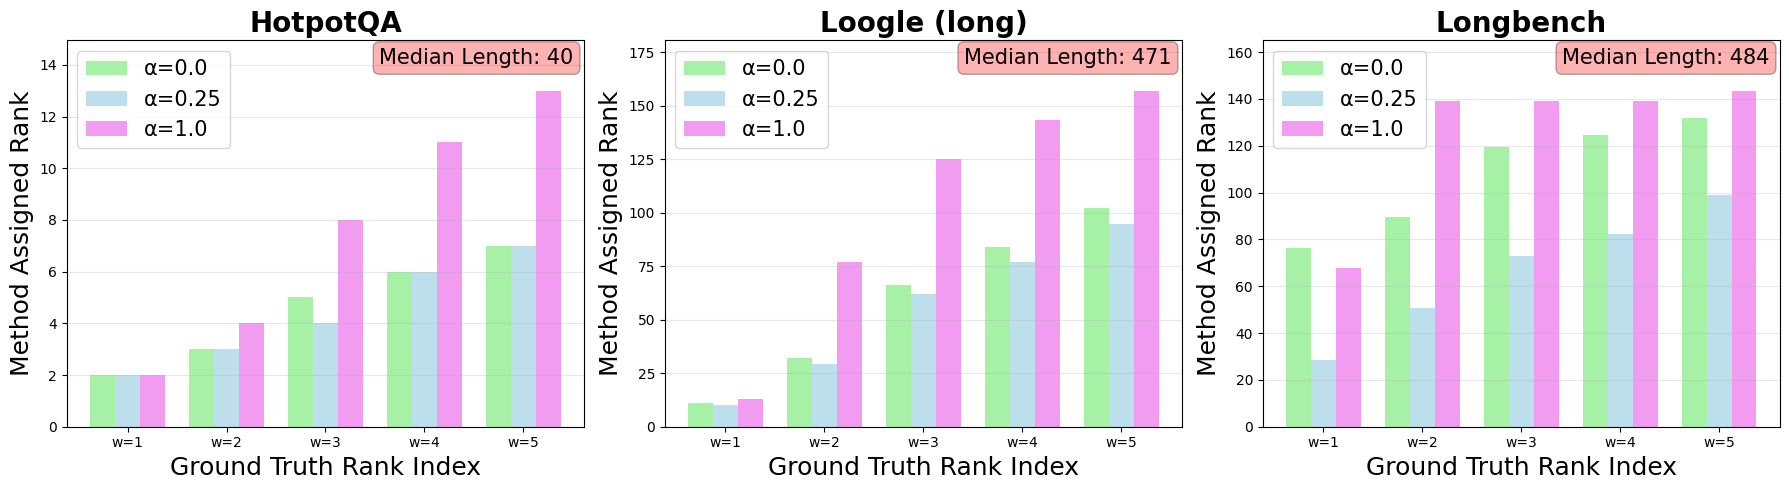

In [ ]:
# Alpha parameter comparison for TreeFinder
alpha_data = {
    "HotpotQA": {
        "0.0": {
            "Rank": [2.0, 3.0, 5.0, 6.0, 7.0],
            "Time": 4.15,
            "Calls": 26.2,
            "Length": 40
        },
        "0.25": {
            "Rank": [2.0, 3.0, 4.0, 6.0, 7.0],
            "Time": 5.70,
            "Calls": 46.8,
            "Length": 40
        },
        "1.0": {
            "Rank": [2.0, 4.0, 8.0, 11.0, 13.0],
            "Time": 5.70,
            "Calls": 23.8,
            "Length": 40
        }
    },
    "Loogle (long)": {
        "0.0": {
            "Rank": [11.0, 32.0, 66.0, 84.0, 102.0],
            "Time": 11.46,
            "Calls": 45.4,
            "Length": 471
        },
        "0.25": {
            "Rank": [10.0, 29.5, 62.0, 77.0, 94.5],
            "Time": 79.58,
            "Calls": 97.1,
            "Length": 471
        },
        "1.0": {
            "Rank": [13.0, 77.0, 125.0, 143.5, 157.0],
            "Time": 75.05,
            "Calls": 49.6,
            "Length": 471
        }
    },
    "Longbench": {
        "0.0": {
            "Rank": [76.5, 89.5, 119.5, 124.5, 132.0],
            "Time": 10.93,
            "Calls": 43.2,
            "Length": 484
        },
        "0.25": {
            "Rank": [28.5, 50.5, 73.0, 82.5, 99.0],
            "Time": 82.41,
            "Calls": 98.9,
            "Length": 484
        },
        "1.0": {
            "Rank": [68.0, 139.0, 139.0, 139.0, 143.5],
            "Time": 74.40,
            "Calls": 50.5,
            "Length": 484
        }
    }
}

# Create 3 subplots for alpha comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets_alpha = ["HotpotQA", "Loogle (long)", "Longbench"]
alphas = ["0.0", "0.25", "1.0"]
colors = ['lightgreen', 'lightblue', 'violet']

for idx, ds in enumerate(datasets_alpha):
    ax = axes[idx]
    
    # Get ranks for each alpha value
    width = 0.25
    
    for alpha_idx, alpha in enumerate(alphas):
        ranks = alpha_data[ds][alpha]["Rank"]
        x_pos = np.arange(len(ranks)) + alpha_idx * width
        ax.bar(x_pos, ranks, width, label=f'α={alpha}', alpha=0.8, color=colors[alpha_idx])
    
    # Determine y-axis limits
    all_ranks = [alpha_data[ds][a]["Rank"] for a in alphas]
    max_rank = max(max(r) for r in all_ranks)
    ax.set_ylim(0, max_rank * 1.15)
    
    # Add median length annotation
    median_len = alpha_data[ds]["0.0"]["Length"]
    ax.text(0.98, 0.98, f'Median Length: {median_len}', 
            transform=ax.transAxes, fontsize=15, verticalalignment='top', 
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))
    
    # Customize subplot
    ax.set_xlabel('Ground Truth Rank Index', fontsize=18)
    ax.set_ylabel('Method Assigned Rank', fontsize=18)
    ax.set_title(f'{ds}', fontsize=20, fontweight='bold')
    ax.legend(fontsize=15)
    ax.grid(axis='y', alpha=0.3)
    ax.set_xticks(np.arange(5) + width)
    ax.set_xticklabels(['w=1', 'w=2', 'w=3', 'w=4', 'w=5'])

plt.tight_layout()
plt.show()

# Save as PDF
fig.savefig('results/alpha_comparison_plot.pdf')